In [89]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_FILE = PROJECT_ROOT/"data"/"clean"/"clean_vietnam-health.csv"

df = pd.read_csv(DATA_FILE)

# What Ages are Coming to Health Clinics?

In [90]:
print(df["Age"].isna().sum())
print(df["Age"].describe())

0
count    2068.000000
mean       29.169246
std        10.091472
min        13.000000
25%        22.000000
50%        27.000000
75%        33.000000
max        83.000000
Name: Age, dtype: float64


Text(0.5, 1.0, 'Age Distribution of Patients')

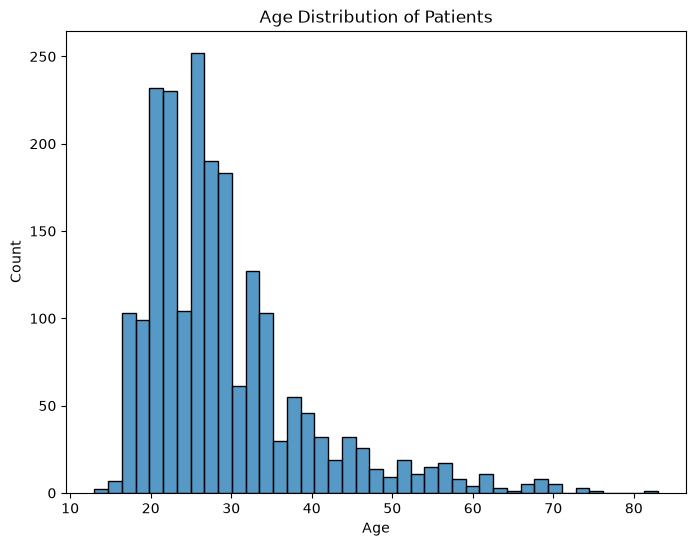

In [91]:
fig,ax = plt.subplots(figsize=(8,6))
sns.histplot(data=df, x="Age")
ax.set_title("Age Distribution of Patients")

The mean age is about 29 but the data is skewed so the median 27 might be a better measure of center, but either way the average age is mid-late twenties

In [92]:
df["Age_gr"] = pd.Categorical(df["Age_gr"], ordered=True, categories=["<18", "18-29", "30-39", "40-49", ">=50"])
df["Age_gr"].value_counts(sort=False)

Age_gr
<18        56
18-29    1250
30-39     489
40-49     154
>=50      119
Name: count, dtype: int64

Text(0.5, 1.0, 'Number of Patients by Age Group')

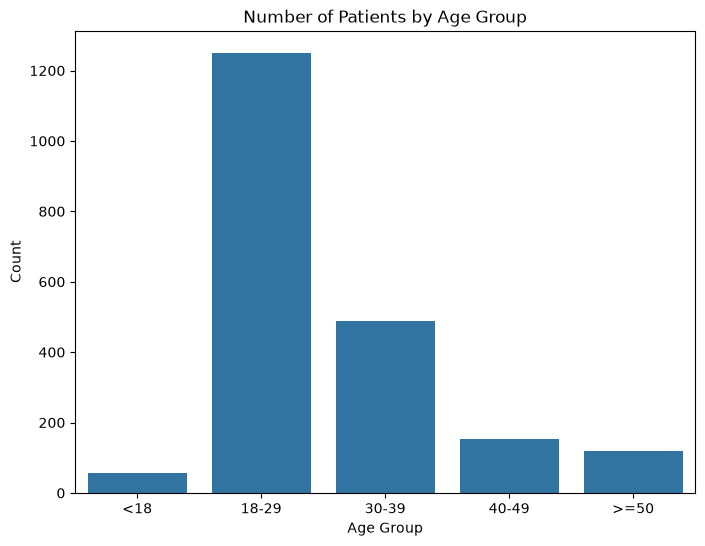

In [93]:
fig,ax = plt.subplots(figsize=(8,6))
sns.countplot(data=df, x="Age_gr")
ax.set_xlabel("Age Group")
ax.set_ylabel("Count")
ax.set_title("Number of Patients by Age Group")



In [94]:
print(df["Jobstt"].value_counts(sort=False))

Jobstt
student       548
unstable      171
stable       1123
other         104
housewife      85
retirer        37
Name: count, dtype: int64


Text(0.5, 1.0, 'Number of Patients by Job Status')

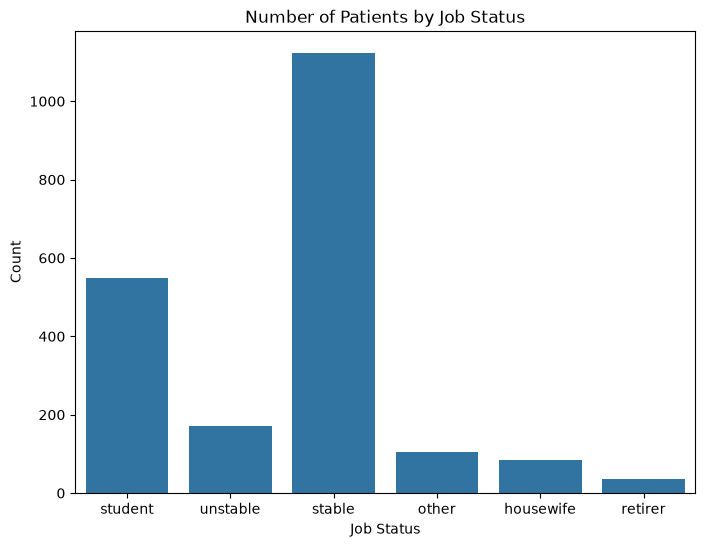

In [95]:
fig,ax = plt.subplots(figsize=(8,6))
sns.countplot(data=df, x="Jobstt")
ax.set_xlabel("Job Status")
ax.set_ylabel("Count")
ax.set_title("Number of Patients by Job Status")


In [96]:
pd.crosstab( index=df["Age_gr"], columns=df["Jobstt"], normalize='index', margins=True)

Jobstt,housewife,other,retirer,stable,student,unstable
Age_gr,,,,,,
<18,0.000000,0.000000,0.000000,0.000000,0.982143,0.017857
18-29,0.027200,0.037600,0.000800,0.468000,0.391200,0.075200
30-39,0.053170,0.044990,0.000000,0.820041,0.006135,0.075665
40-49,0.097403,0.103896,0.006494,0.681818,0.006494,0.103896
>=50,0.084034,0.159664,0.294118,0.268908,0.000000,0.193277
All,0.041103,0.050290,0.017892,0.543037,0.264990,0.082689


Again, this shows a majority of the patients are in or around their twenties.

Inference: Ths could be due to their accessibility to clinics. Those younger than this group may not have anoyone that can get them to to doctors and they may not be able to get there on their own. Similarly, the elderly may have a hard time getting around and need assistance. Of those in the 30-39 age group, 82% of them have jobs meaning they may not have the time to get themselves or their family members to the clinic. Or maybe they cannot afford to miss a day of work for illness or to get a checkup. No matter the reason for not going to the clinic, it is clear that the age demographic to focus efforts on should be mostly children and the elderly.

# How does Education Impact Participant's Responses? 

In [97]:
df['Edu'] = pd.Categorical(df['Edu'], categories = ['Middle', 'High', 'Grad', 'PostGrad'], ordered = True)
df['Edu'].value_counts(sort = False,normalize = True)

Edu
Middle      0.201161
High        0.068665
Grad        0.668762
PostGrad    0.061412
Name: proportion, dtype: float64

A majority of the respondents in the survey have achieved a college or graduate degree, so it is important to note repsonses in other education groups may be skewed.

In [98]:
pd.crosstab(df['Edu'],df['HthyPriority'], normalize='index') * 100

HthyPriority,no,yes
Edu,,
Middle,21.153846,78.846154
High,19.718310,80.281690
Grad,18.799711,81.200289
PostGrad,13.385827,86.614173


When looking at responses to if respondents view health as a priority, we see that as education level increases, more peercentage see it as a priority. Despite this increase, we generally do see that a majority of participants in each grade level report that health is a priority

# Does Location Impact How People Respond?

In [99]:
place_counts = df['place'].value_counts(sort = True)
place_counts.head(15)

place
hanoi        1638
hungyen       155
hochiminh      35
namdinh        30
phutho         19
bacninh        18
thanhhoa       18
hanam          17
haiduong       17
bacgiang       15
quangninh      13
ninhbinh       13
thaibinh       12
nghean          9
haiphong        9
Name: count, dtype: int64

From this, we see that a majority of the participants in the survey are from Hanoi, Vietnam's capital.

In [100]:
# Want to try to consider only places with at least 10 patients, so we can have a more reliable analysis
places_enough_data = place_counts[place_counts >= 10].index
places_enough_data

Index(['hanoi', 'hungyen', 'hochiminh', 'namdinh', 'phutho', 'bacninh',
       'thanhhoa', 'hanam', 'haiduong', 'bacgiang', 'quangninh', 'ninhbinh',
       'thaibinh'],
      dtype='str', name='place')

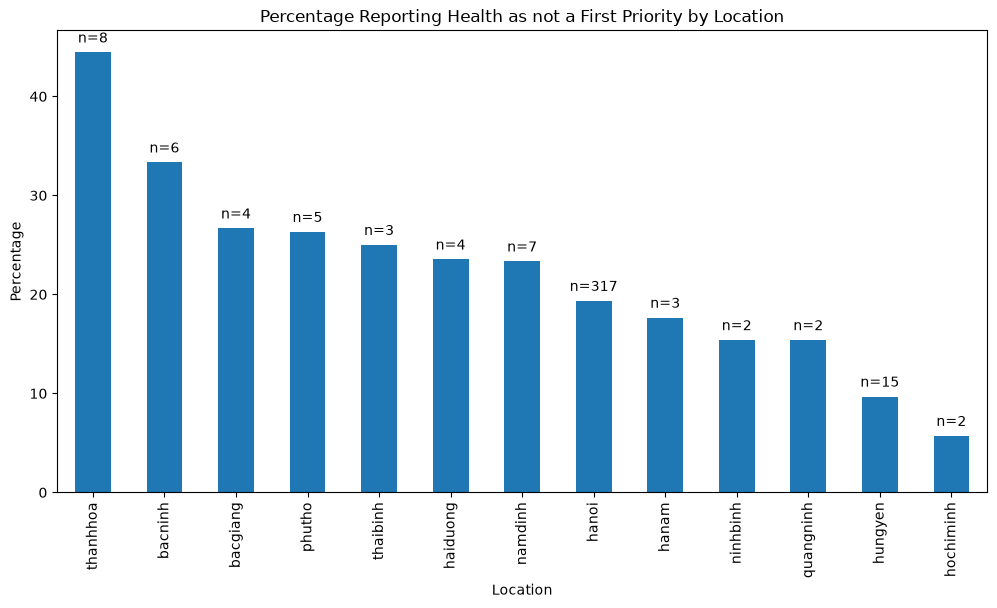

In [101]:
place_health = pd.crosstab(
    df['place'],
    df['HthyPriority'],
    normalize='index'
) * 100

place_health = place_health.loc[
    place_health.index.isin(places_enough_data)
]

place_health = place_health['no'].sort_values(ascending=False)


place_health_counts = pd.crosstab(
    df['place'],
    df['HthyPriority']
)

place_health_counts = place_health_counts.loc[
    place_health_counts.index.isin(places_enough_data)
]

place_health_counts = place_health_counts['no']

place_health_counts = place_health_counts.loc[place_health.index]


place_health.plot(kind='bar', figsize=(12, 6))

plt.ylabel('Percentage')
plt.xlabel('Location')
plt.title('Percentage Reporting Health as not a First Priority by Location')
plt.xticks(rotation=90)

for i, count in enumerate(place_health_counts):
    plt.text(
        i,
        place_health.iloc[i] + 1,
        f'n={count}',
        ha='center'
    )

plt.show()

When considering places where health is not considered a priority, we can see that thanh hoa is an area where over 40% of respondents said no. However, due to a small sample size from that area, answers may be skewed.

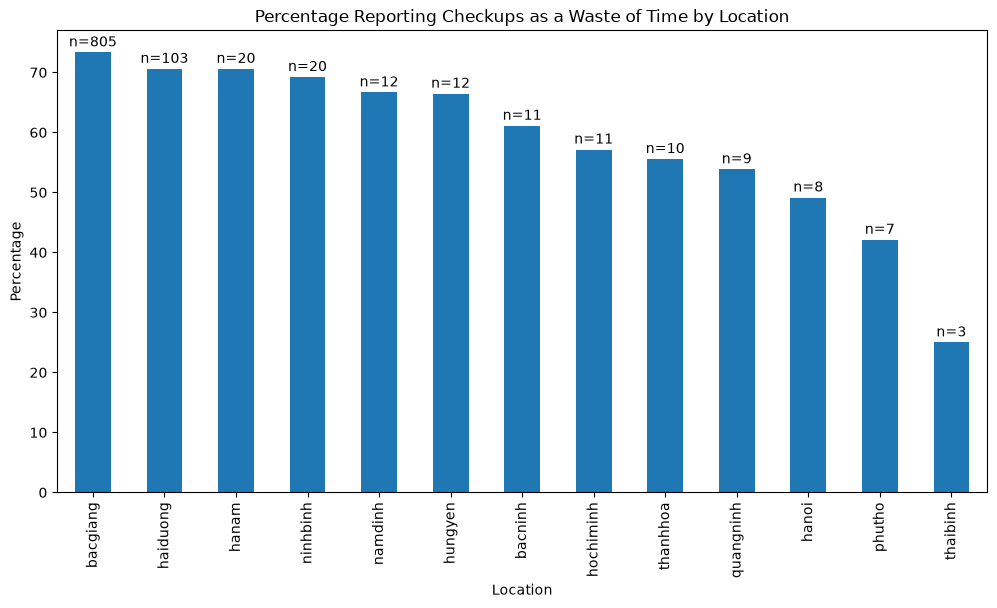

In [102]:
place_wsttime = pd.crosstab(
    df['place'],
    df['Wsttime'],
    normalize='index'
) * 100

place_wsttime = place_wsttime.loc[
    place_wsttime.index.isin(places_enough_data)
]

place_wsttime = place_wsttime['yes'].sort_values(ascending=False)

place_wsttime_counts = pd.crosstab(
    df['place'],
    df['Wsttime'],
) 

place_wsttime_counts = place_wsttime_counts.loc[
    place_wsttime_counts.index.isin(places_enough_data)
]

place_wsttime_counts = place_wsttime_counts['yes'].sort_values(ascending=False)

place_wsttime.plot(kind='bar', figsize=(12, 6))

plt.ylabel('Percentage')
plt.xlabel('Location')
plt.title('Percentage Reporting Checkups as a Waste of Time by Location')
plt.xticks(rotation=90)

for i, count in enumerate(place_wsttime_counts):
    plt.text(
        i,
        place_wsttime.iloc[i] + 1,
        f'n={count}',
        ha='center'
    )

plt.show()

We can see that a majority of participants in a lot of these areas view checkups as a waste of time. 

In [103]:
place_counts_filtered = place_counts[
    place_counts.index.isin(places_enough_data)
]

place_attitudes = pd.DataFrame({
    'Number of Responses': place_counts_filtered,
    'Not First Priority (%)': place_health,
    'Waste of Time (%)': place_wsttime
})

place_attitudes = place_attitudes.sort_values(
    'Number of Responses',
    ascending=False
)

place_attitudes

,Number of Responses,Not First Priority (%),Waste of Time (%)
place,,,
hanoi,1638,19.352869,49.145299
hungyen,155,9.677419,66.451613
hochiminh,35,5.714286,57.142857
namdinh,30,23.333333,66.666667
phutho,19,26.315789,42.105263
bacninh,18,33.333333,61.111111
thanhhoa,18,44.444444,55.555556
haiduong,17,23.529412,70.588235
hanam,17,17.647059,70.588235


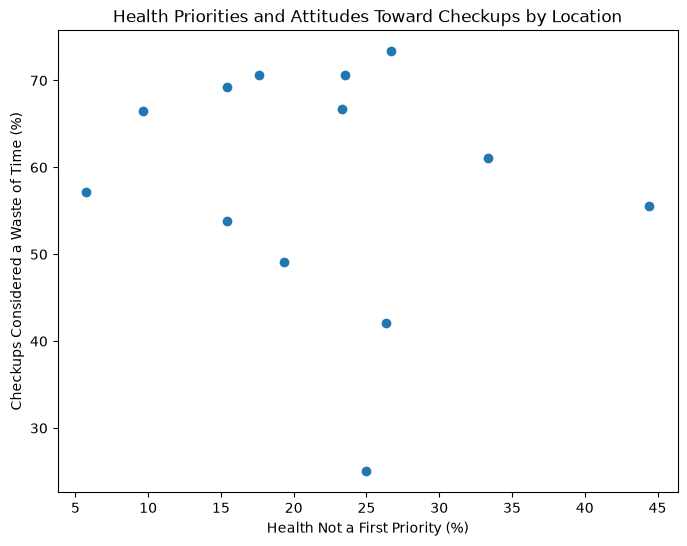

Correlation coefficient: -0.15215109305030683


In [104]:
plt.figure(figsize=(8, 6))

plt.scatter(
    place_attitudes['Not First Priority (%)'],
    place_attitudes['Waste of Time (%)']
)

plt.xlabel('Health Not a First Priority (%)')
plt.ylabel('Checkups Considered a Waste of Time (%)')
plt.title('Health Priorities and Attitudes Toward Checkups by Location')

plt.show()

correlation = place_attitudes['Not First Priority (%)'].corr(
    place_attitudes['Waste of Time (%)']
)

print("Correlation coefficient:", correlation)

It is important to note that, we dont see a strong correlation between how respondents view the importance of health and whether or not they believe it is a waste of time. So even if they see it as a priority, they may possibly still see it as a waste of time.

# How does Perception of Public Health differ by Age?

In [112]:
df['CHPerc'] = df['CHPerc'].replace('unknown', pd.NA)

df['CHPerc'] = pd.Categorical(
    df['CHPerc'],
    categories=['bad', 'quite', 'good'],
    ordered=True
)

In [119]:
age_health = pd.crosstab(
    df['Age_gr'],
    df['CHPerc'],
    normalize='index'
) * 100

age_health

CHPerc,bad,quite,good
Age_gr,,,
<18,12.765957,57.446809,29.787234
18-29,37.693006,43.505904,18.801090
30-39,49.408983,32.860520,17.730496
40-49,49.264706,33.823529,16.911765
>=50,51.485149,30.693069,17.821782


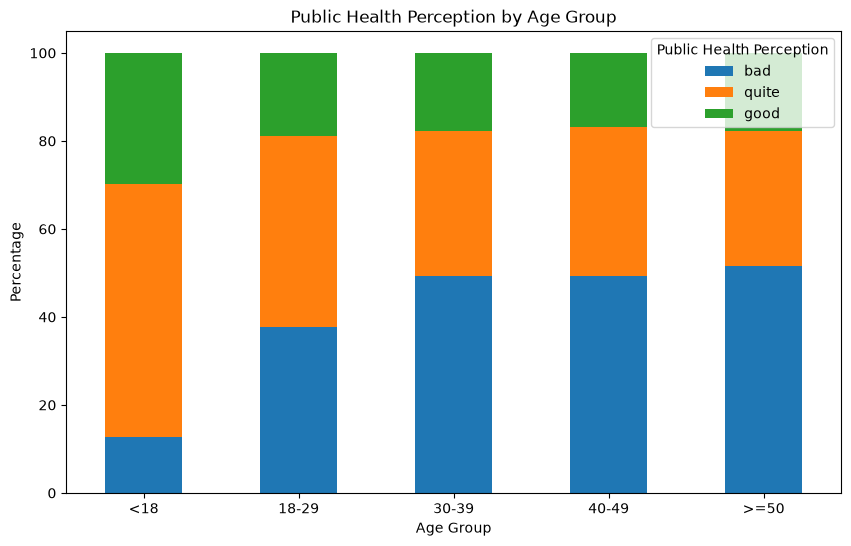

In [120]:
age_health.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.ylabel('Percentage')
plt.xlabel('Age Group')
plt.title('Public Health Perception by Age Group')
plt.xticks(rotation=0)
plt.legend(title='Public Health Perception')

plt.show()

From this chart, we can see that people's perception of public health seems to be more negative as their age group increases. The younger age group seems to have a more positive perception. From this it may be important to target public health education towards the older generation or target changes to meet that demographic's need.

# Could IT be a Practical Solution?

To address the issue that these age groups as well as other demographics are not getting regular health exams, one solution could be the use of IT. As AI and technology now becomes a part of everyday life, could it be a solution to this problem?

In [52]:
df["Edu"] = pd.Categorical(df["Edu"], ordered=True, categories=["Middle", "High", "Grad", "PostGrad"])
print(df["Edu"].value_counts(sort=False))

Edu
Middle       416
High         142
Grad        1383
PostGrad     127
Name: count, dtype: int64


In [53]:
prop_table_use = (pd.crosstab(df["Edu"], df["UseIT"], normalize="index") *100).reset_index()
prop_table_use

UseIT,Edu,maybe,no,yes
0,Middle,30.048077,30.769231,39.182692
1,High,33.098592,44.366197,22.535211
2,Grad,36.659436,18.944324,44.396240
3,PostGrad,33.070866,18.110236,48.818898


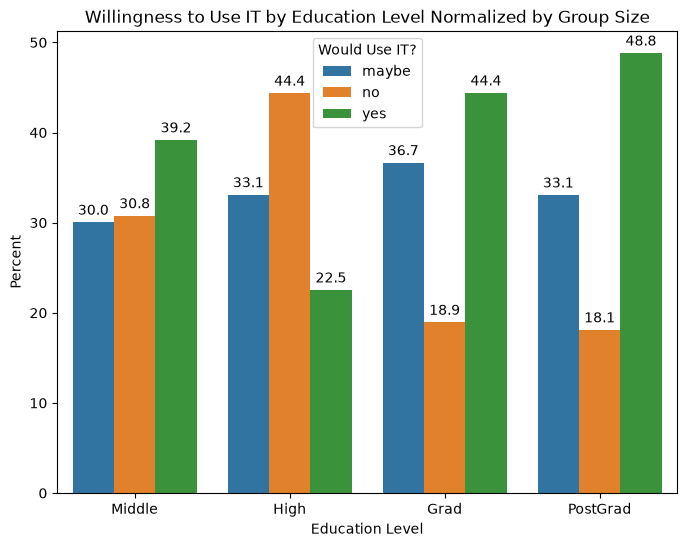

In [54]:
fig,ax = plt.subplots(figsize=(8,6))

df_long = prop_table_use.melt(
    id_vars="Edu",
    var_name="UseIT",
    value_name="percentage"
)

sns.barplot(
    data=df_long,
    x="Edu",
    y="percentage",
    hue="UseIT",
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.title("Willingness to Use IT by Education Level Normalized by Group Size")
plt.ylabel("Percent")
plt.xlabel("Education Level")
plt.legend(title="Would Use IT?")

Within each education group, the biggest percentage is those who said yes except for the High School education group whose greatest percentage response was no. Further exploration would be needed to understand the High School groups perspective as to why they would not use IT. Perhaps what they have learned up until this point has made them wary of IT. However, IT may be a promising solution for the other groups due to their willingness, and efforts could be put towards those in High School explaining the technology and addressing their concerns.

In [55]:
prop_table_after = (pd.crosstab(df["Edu"], df["AfterIT"], normalize="index") *100).reset_index()
prop_table_after

AfterIT,Edu,maybe,no,yes
0,Middle,41.346154,19.471154,39.182692
1,High,39.436620,37.323944,23.239437
2,Grad,44.468547,14.822849,40.708604
3,PostGrad,44.881890,11.023622,44.094488


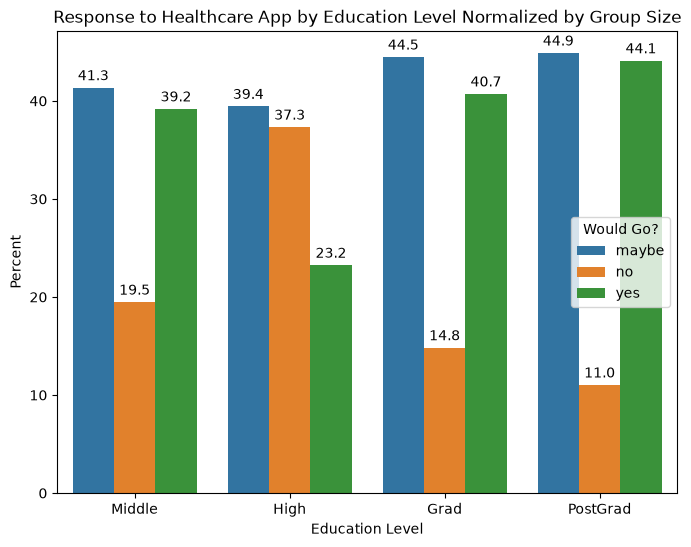

In [56]:
fig,ax = plt.subplots(figsize=(8,6))

df_long = prop_table_after.melt(
    id_vars="Edu",
    var_name="AfterIT",
    value_name="percentage"
)

sns.barplot(
    data=df_long,
    x="Edu",
    y="percentage",
    hue="AfterIT",
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)
plt.title("Response to Healthcare App by Education Level Normalized by Group Size")
plt.ylabel("Percent")
plt.xlabel("Education Level")
plt.legend(title="Would Go?")

This variable indications whether or not a patient would arrange a check-up if a healthcare app indicated they needed one. The highest percentage across all education groups is the 'maybe' response. This implies that no matter what education the patient has, they may have concerns about how much they can trust the app to make recommendations or they may not be inclined to make an appointment just based on an app. However, the largest percentage is not no. Therefore, IT is still a path that could be explored to try an get patients to get check-ups, but concerns would need to be addressed.

Overall, the age demographics to target are the young and the elderly. Most patients are in their mid-to-late twenties. To reach those who are not getting to the clinics, IT may be a solution. However, before implementation, we need to explore why some people are wary of IT recommendations.

In [ ]:
df['CHPerc'].unique()

<StringArray>
['quite', 'bad', 'unknown', 'good']
Length: 4, dtype: str